# Bloque 7 — Grafos e IA
## Notebook 00: Red de contactos desde un histórico de llamadas

---

### ¿Qué problema resolvemos?

Dado un fichero de llamadas — los registros que cualquier operadora tiene — queremos responder automáticamente:

- ¿Con quién habla más cada número?
- ¿Hay subgrupos que se comunican principalmente entre sí?
- ¿Quién actúa como intermediario entre grupos distintos?

Este pipeline aparece en investigaciones forenses, periodismo de datos, inteligencia y detección de fraude. La herramienta es un **grafo ponderado**: nodos (teléfonos) conectados por aristas cuyo peso es el número de llamadas entre ellos.

```
Histórico CSV  →  Grafo ponderado  →  Métricas  →  Comunidades  →  Visualización interactiva
                                                                                ↓
                                                                    Notebook 01: agente IA
```

### Arquitectura del dataset sintético

| Tipo de nodo | Cantidad | Descripción |
|---|---|---|
| Teléfonos sujeto (core) | 10 | 3 grupos internos: A (4), B (3), C (3) |
| Terceros puente | 30 | Llamados por teléfonos de **grupos distintos** — crean los puentes detectables |
| Terceros únicos | 500 | 50 por teléfono sujeto — contactos exclusivos de cada uno |
| **Total nodos** | **~540** | |
| **Total llamadas** | **~15 000** | ~1 500 por teléfono sujeto |

In [1]:
# ─── GENERAR DATASET SINTÉTICO ────────────────────────────────────────────────
import numpy as np
import pandas as pd
from pathlib import Path

rng = np.random.default_rng(42)
Path('data').mkdir(exist_ok=True)

# ── Arquitectura de la red ─────────────────────────────────────────────────────
GRUPOS = {
    'A': [f'+34600{i:06d}' for i in range(1, 5)],   # 4 teléfonos
    'B': [f'+34600{i:06d}' for i in range(5, 8)],   # 3 teléfonos
    'C': [f'+34600{i:06d}' for i in range(8, 11)],  # 3 teléfonos
}
CORE = [t for tels in GRUPOS.values() for t in tels]

# Terceros compartidos: llamados por teléfonos de grupos distintos (crean puentes)
PUENTES = {
    'AB': [f'+34700{i:06d}' for i in range(1,  11)],
    'BC': [f'+34700{i:06d}' for i in range(11, 21)],
    'AC': [f'+34700{i:06d}' for i in range(21, 31)],
}

# Únicos: 50 contactos propios de cada teléfono sujeto
UNICOS = {
    tel: [f'+34800{(idx * 50 + i):06d}' for i in range(50)]
    for idx, tel in enumerate(CORE)
}

# ── Distribución horaria realista (picos a media mañana y media tarde) ─────────
_pesos_hora = np.array([
    0.01, 0.01, 0.01, 0.01, 0.01, 0.02, 0.03,  # 0–6h
    0.05, 0.08, 0.10, 0.09, 0.07, 0.06, 0.07,  # 7–13h
    0.05, 0.08, 0.09, 0.07, 0.05, 0.03, 0.02,  # 14–20h
    0.02, 0.01, 0.01,                            # 21–23h
])
_pesos_hora /= _pesos_hora.sum()

def ts_aleatorio():
    dia = pd.Timestamp('2024-01-01') + pd.Timedelta(days=int(rng.integers(0, 90)))
    hora = int(rng.choice(24, p=_pesos_hora))
    return dia + pd.Timedelta(hours=hora, minutes=int(rng.integers(0, 60)))

def duracion():
    return min(int(rng.exponential(90)) + 5, 3600)

# ── Generar registros ──────────────────────────────────────────────────────────
registros = []

for grupo, telefonos in GRUPOS.items():
    puentes_g = (PUENTES['AB'] + PUENTES['AC'] if grupo == 'A' else
                 PUENTES['AB'] + PUENTES['BC'] if grupo == 'B' else
                 PUENTES['BC'] + PUENTES['AC'])
    for tel in telefonos:
        peers = [t for t in telefonos if t != tel]
        for _ in range(400):  # llamadas intragrupo
            registros.append((tel, rng.choice(peers), duracion(), ts_aleatorio()))
        for _ in range(300):  # llamadas a puentes
            registros.append((tel, rng.choice(puentes_g), duracion(), ts_aleatorio()))
        for _ in range(800):  # llamadas a únicos
            registros.append((tel, rng.choice(UNICOS[tel]), duracion(), ts_aleatorio()))

df = (pd.DataFrame(registros, columns=['origen', 'destino', 'duracion_s', 'timestamp'])
        .sort_values('timestamp')
        .reset_index(drop=True))

df.to_csv('data/llamadas.csv', index=False)

n_nodos = pd.concat([df['origen'], df['destino']]).nunique()
print(f'Dataset generado: {len(df):,} registros | {n_nodos:,} teléfonos únicos')
print(f'Rango temporal  : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
df.head(8)

Dataset generado: 15,000 registros | 540 teléfonos únicos
Rango temporal  : 2024-01-01 → 2024-03-30


,origen,destino,duracion_s,timestamp
0,+34600000005,+34600000006,42,2024-01-01 00:03:00
1,+34600000001,+34800000004,56,2024-01-01 01:14:00
2,+34600000008,+34700000015,55,2024-01-01 01:30:00
3,+34600000005,+34600000006,48,2024-01-01 01:55:00
4,+34600000001,+34800000039,86,2024-01-01 03:31:00
5,+34600000001,+34600000004,71,2024-01-01 04:07:00
6,+34600000001,+34800000005,298,2024-01-01 04:46:00
7,+34600000004,+34800000150,18,2024-01-01 04:47:00


Top 5 teléfonos más activos:
  +34600000003: 1,928 llamadas
  +34600000008: 1,926 llamadas
  +34600000004: 1,920 llamadas
  +34600000005: 1,906 llamadas
  +34600000007: 1,902 llamadas

Duración media de llamada: 95s
Duración mediana         : 67s


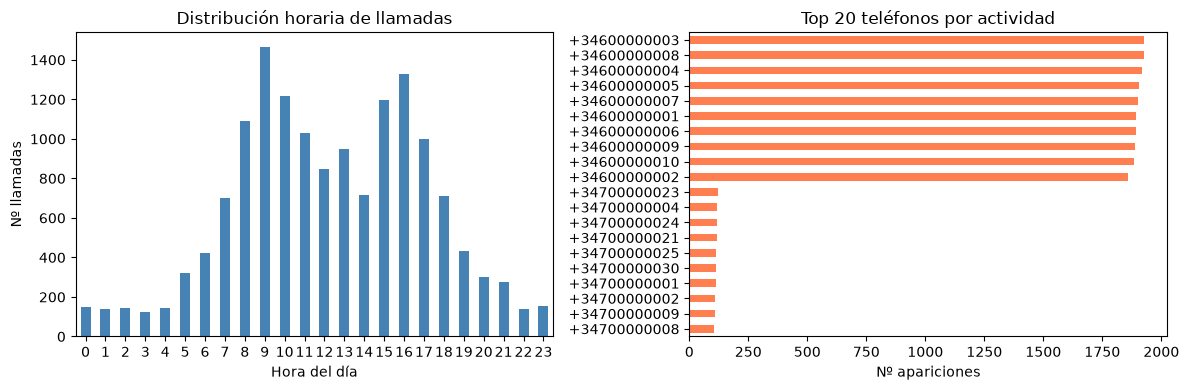

In [2]:
# ─── EXPLORACIÓN DEL DATASET ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Nodos más activos (por nº de apariciones como origen o destino)
conteo = pd.concat([df['origen'], df['destino']]).value_counts()
print(f'Top 5 teléfonos más activos:')
for tel, cnt in conteo.head(5).items():
    print(f'  {tel}: {cnt:,} llamadas')

print(f'\nDuración media de llamada: {df["duracion_s"].mean():.0f}s')
print(f'Duración mediana         : {df["duracion_s"].median():.0f}s')

# Distribución horaria
df['hora'] = pd.to_datetime(df['timestamp']).dt.hour
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

df['hora'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Distribución horaria de llamadas')
ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Nº llamadas')
ax1.tick_params(axis='x', rotation=0)

# Top 20 teléfonos por actividad
conteo.head(20).plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Top 20 teléfonos por actividad')
ax2.set_xlabel('Nº apariciones')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## Construir el grafo

### Conceptos clave

**Grafo ponderado**: cada arista tiene un **peso** — aquí, el número total de llamadas entre el par de teléfonos.

**Métricas de centralidad** — responden "¿quién es importante?":

| Métrica | Pregunta que responde |
|---|---|
| **Grado ponderado** (strength) | ¿Con cuánta actividad total se comunica? |
| **Betweenness** | ¿Por cuántas rutas cortas pasa? → intermediarios |
| **Closeness** | ¿A qué distancia media está del resto? → difusores de info |

**Detección de comunidades** (Leiden): agrupa nodos que se conectan más entre sí que con el exterior. El resultado ideal en nuestro dataset: 3 comunidades correspondientes a los grupos A, B y C.

In [3]:
# ─── CONSTRUIR GRAFO CON IGRAPH ───────────────────────────────────────────────
import igraph as ig

# Agregar llamadas por par (no dirigido: orden del par no importa)
pares = np.sort(df[['origen', 'destino']].values, axis=1)
df_pares = pd.DataFrame(pares, columns=['a', 'b'])
df_pares['duracion_s'] = df['duracion_s'].values

aristas = df_pares.groupby(['a', 'b']).agg(
    n_llamadas=('duracion_s', 'count'),
    duracion_media=('duracion_s', 'mean'),
).reset_index()

# Lista de nodos únicos
nodos = sorted(set(aristas['a']) | set(aristas['b']))
nodo_idx = {n: i for i, n in enumerate(nodos)}

# Crear grafo
g = ig.Graph(n=len(nodos), directed=False)
g.vs['nombre'] = nodos
g.add_edges([(nodo_idx[r['a']], nodo_idx[r['b']]) for _, r in aristas.iterrows()])
g.es['peso'] = aristas['n_llamadas'].tolist()
g.es['duracion_media'] = aristas['duracion_media'].round(1).tolist()

# Peso inverso: para betweenness y closeness (más llamadas = camino más corto)
g.es['inv_peso'] = [1.0 / max(w, 1) for w in g.es['peso']]

print(f'Grafo construido:')
print(f'  Nodos  : {g.vcount():,}')
print(f'  Aristas: {g.ecount():,}')
print(f'  Denso  : {g.ecount() / (g.vcount() * (g.vcount()-1) / 2):.4%}')

Grafo construido:
  Nodos  : 540
  Aristas: 712
  Denso  : 0.4892%


In [4]:
# ─── MÉTRICAS DE CENTRALIDAD ──────────────────────────────────────────────────
# Grado ponderado (strength): suma de pesos de aristas incidentes
grado_pond = g.strength(weights='peso')

# Betweenness: nº de rutas cortas que pasan por cada nodo (inv_peso como distancia)
print('Calculando betweenness...')
btw = g.betweenness(weights='inv_peso', directed=False)

# Closeness: inverso de la distancia media al resto de nodos
cls = g.closeness(weights='inv_peso')

# Etiquetar tipo de nodo
def tipo_nodo(nombre):
    for g_name, tels in GRUPOS.items():
        if nombre in tels:
            return f'Grupo {g_name}'
    for b_name, tels in PUENTES.items():
        if nombre in tels:
            return f'Puente {b_name}'
    return 'Único'

df_nodos = pd.DataFrame({
    'nombre'      : nodos,
    'tipo'        : [tipo_nodo(n) for n in nodos],
    'grado_pond'  : grado_pond,
    'betweenness' : btw,
    'closeness'   : cls,
})

print('\nTop 15 por betweenness (intermediarios de la red):')
print(df_nodos.nlargest(15, 'betweenness')[['nombre', 'tipo', 'grado_pond', 'betweenness']]
              .to_string(index=False))

Calculando betweenness...

Top 15 por betweenness (intermediarios de la red):


      nombre      tipo  grado_pond  betweenness
+34600000007   Grupo B      1902.0      66654.0
+34600000003   Grupo A      1928.0      52894.0
+34600000010   Grupo C      1884.0      34930.0
+34600000001   Grupo A      1894.0      34609.0
+34600000009   Grupo C      1890.0      34574.5
+34600000008   Grupo C      1926.0      34518.5
+34700000004 Puente AB       118.0      34221.0
+34600000005   Grupo B      1906.0      27337.0
+34600000006   Grupo B      1892.0      26857.0
+34600000004   Grupo A      1920.0      26855.0
+34600000002   Grupo A      1858.0      26592.0
+34700000012 Puente BC       100.0      16575.0
+34700000021 Puente AC       117.0      16014.0
+34700000030 Puente AC       114.0      13311.0
+34700000011 Puente BC        92.0       8160.0


In [5]:
# ─── DETECCIÓN DE COMUNIDADES CON LEIDEN ─────────────────────────────────────
import leidenalg

particion = leidenalg.find_partition(
    g,
    leidenalg.ModularityVertexPartition,
    weights='peso',
    seed=42,
)
g.vs['comunidad'] = particion.membership
df_nodos['comunidad'] = particion.membership

# Resumen de comunidades
resumen_com = df_nodos.groupby('comunidad').agg(
    n_nodos=('nombre', 'count'),
    tipos=('tipo', lambda x: ', '.join(sorted(x.unique()))),
).reset_index()

print(f'Comunidades detectadas: {len(resumen_com)}')
print(f'Modularidad: {particion.modularity:.4f}  (1.0 = comunidades perfectas)\n')
print(resumen_com.to_string(index=False))

Comunidades detectadas: 3
Modularidad: 0.5220  (1.0 = comunidades perfectas)

 comunidad  n_nodos                                tipos
         0      218 Grupo A, Puente AB, Puente AC, Único
         1      161 Grupo B, Puente AB, Puente BC, Único
         2      161 Grupo C, Puente AC, Puente BC, Único


In [6]:
# ─── VISUALIZACIÓN INTERACTIVA CON PLOTLY ────────────────────────────────────
import plotly.graph_objects as go

# Layout Fruchterman-Reingold (agrupa por densidad de conexiones)
# np.random.seed para reproducibilidad (igraph usa el RNG global de numpy para el layout)
print('Calculando layout (puede tardar unos segundos)...')
np.random.seed(42)
layout = g.layout_fruchterman_reingold(weights='peso', niter=500)
x_n = [p[0] for p in layout]
y_n = [p[1] for p in layout]

# Aristas (una sola traza, transparente)
edge_x, edge_y = [], []
for e in g.es:
    edge_x += [x_n[e.source], x_n[e.target], None]
    edge_y += [y_n[e.source], y_n[e.target], None]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y, mode='lines',
    line=dict(width=0.4, color='rgba(150,150,150,0.3)'),
    hoverinfo='none', showlegend=False,
)

# Colores y tamaños por tipo de nodo
PALETA = {
    'Grupo A' : ('#1f77b4', 22), 'Grupo B' : ('#2ca02c', 22), 'Grupo C' : ('#ff7f0e', 22),
    'Puente AB': ('#9467bd', 12), 'Puente BC': ('#d62728', 12), 'Puente AC': ('#8c564b', 12),
    'Único'    : ('#cccccc',  4),
}

nodo_traces = []
for tipo, (color, size) in PALETA.items():
    mask = df_nodos['tipo'] == tipo
    if not mask.any():
        continue
    sub = df_nodos[mask].reset_index(drop=True)
    idxs = [nodo_idx[n] for n in sub['nombre']]
    mostrar_label = tipo.startswith('Grupo')
    trace = go.Scatter(
        x=[x_n[i] for i in idxs],
        y=[y_n[i] for i in idxs],
        mode='markers+text' if mostrar_label else 'markers',
        text=sub['nombre'].str[-6:] if mostrar_label else None,
        textposition='top center',
        textfont=dict(size=8),
        marker=dict(size=size, color=color, line=dict(width=0.5, color='white')),
        name=tipo,
        hovertext=sub.apply(
            lambda r: (f"{r['nombre']}<br>Tipo: {r['tipo']}<br>"
                       f"Llamadas: {r['grado_pond']:.0f}<br>"
                       f"Comunidad: {r['comunidad']}<br>"
                       f"Betweenness: {r['betweenness']:.0f}"),
            axis=1,
        ),
        hoverinfo='text',
    )
    nodo_traces.append(trace)

fig = go.Figure(
    data=[edge_trace] + nodo_traces,
    layout=go.Layout(
        title='Red de contactos — histórico de llamadas sintético',
        showlegend=True,
        hovermode='closest',
        height=700,
        margin=dict(b=20, l=5, r=5, t=50),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        paper_bgcolor='white',
        plot_bgcolor='white',
    ),
)
fig.show()

Calculando layout (puede tardar unos segundos)...


In [7]:
# ─── EXPORTAR PARA NOTEBOOK 01 ────────────────────────────────────────────────
import pickle

# Grafo con todos los atributos (nombre, comunidad, métricas)
with open('data/grafo.pkl', 'wb') as f:
    pickle.dump(g, f)

# DataFrame de nodos con métricas
df_nodos.to_csv('data/nodos.csv', index=False)

print('Exportado:')
for ruta in ['data/llamadas.csv', 'data/grafo.pkl', 'data/nodos.csv']:
    tam = Path(ruta).stat().st_size
    print(f'  {ruta:<25} {tam/1024:6.1f} KB')

print(f'\nResumen final:')
print(f'  Nodos    : {g.vcount():,}')
print(f'  Aristas  : {g.ecount():,}')
print(f'  Comunidades: {len(set(g.vs["comunidad"]))}')
print(f'  Nodo con mayor betweenness: {df_nodos.nlargest(1, "betweenness")["nombre"].values[0]}')

Exportado:
  data/llamadas.csv          722.2 KB
  data/grafo.pkl              27.5 KB
  data/nodos.csv              26.1 KB

Resumen final:
  Nodos    : 540
  Aristas  : 712
  Comunidades: 3
  Nodo con mayor betweenness: +34600000007
